# 01. Phân tích Khám phá Dữ liệu (EDA)
## Hệ thống Chẩn đoán Bệnh Lá Cây Nông nghiệp — Lúa & Cà phê

**Thực hiện:** Lê Xuân Trí — 23120099
**Giai đoạn:** Phase 2.1 — Phân tích dữ liệu thô
**Ngày cập nhật:** 2026-04-16

---

### Mục lục

1. [Thách thức của tập dữ liệu nông nghiệp](#sec1)
2. [Tổng quan tập dữ liệu](#sec2)
3. [Phân phối lớp dữ liệu](#sec3)
4. [Phân tích kích thước và tỉ lệ ảnh](#sec4)
5. [Phân tích độ sáng và kênh màu RGB](#sec5)
6. [Trực quan hóa mẫu bệnh](#sec6)
7. [Phân tích annotation COCO](#sec7)
8. [Nhận diện cặp bệnh dễ nhầm lẫn](#sec8)
9. [Chỉ số đánh giá Macro F1](#sec9)
10. [Tóm tắt và khuyến nghị tiền xử lý](#sec10)

In [ ]:
# ============================================================
# Environment Setup & Configuration
# ============================================================
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Bootstrap: locate project root and register utils on sys.path ─
_cwd = Path(os.getcwd())
PROJECT_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "src").exists() and (p / "notebooks").exists()),
    _cwd.parent,
)
sys.path.insert(0, str(PROJECT_ROOT / "src" / "utils"))

# ── Project imports ───────────────────────────────────────────
from config import (
    RANDOM_SEED,
    RICE_CLASSES, COFFEE_CLASSES,
    RICE_FOLDER,  COFFEE_FOLDER,
    PALETTE_RICE, PALETTE_COFFEE,
)
from utils import set_seed, load_coco, build_image_df, build_ann_df
from visualize import (
    setup_plot_style,
    sample_color_stats,
    show_sample_grid,
    compute_mean_histogram,
)
from helpers import find_project_root  # verified alias

set_seed(RANDOM_SEED)
setup_plot_style()

# ── Data paths ────────────────────────────────────────────────
RICE_DIR   = PROJECT_ROOT / "src" / "data" / "rice_leaf_disease"
COFFEE_DIR = PROJECT_ROOT / "src" / "data" / "coffee_leaf_disease"

---
<a id="sec1"></a>
## 1. Thách thức của Tập Dữ liệu Nông nghiệp

Trước khi tiến hành bất kỳ phân tích định lượng nào, điều cần thiết là phải nhận thức rõ những thách thức đặc thù của dữ liệu ảnh lá cây thu thập từ thực địa. Những yếu tố này ảnh hưởng trực tiếp đến chiến lược tiền xử lý, lựa chọn mô hình và phương pháp đánh giá.

### 1.1 Biến thiên điều kiện chụp ảnh

Ảnh được thu thập bởi nông dân thông qua điện thoại di động trong điều kiện ánh sáng tự nhiên không kiểm soát. Điều này dẫn đến sự biến động lớn về:
- **Độ sáng và cân bằng trắng:** Ánh sáng buổi sáng, buổi chiều, và ngày âm u tạo ra các dải histogram hoàn toàn khác nhau cho cùng một loại bệnh.
- **Góc chụp và khoảng cách:** Ảnh có thể chứa một lá đơn, nhiều lá chồng nhau, hoặc toàn bộ nhánh cây.
- **Nền ảnh (background):** Đất, cỏ, và các lá không bị bệnh chiếm phần đáng kể diện tích ảnh, tạo ra nhiễu thị giác.

### 1.2 Mất cân bằng lớp (Class Imbalance)

Trong thực tế, một số bệnh phổ biến hơn các bệnh khác, hoặc một số lớp có ít mẫu hơn do khó thu thập. Sự mất cân bằng này có thể dẫn đến mô hình thiên vị về phía lớp đa số, làm suy giảm nghiêm trọng hiệu suất trên các lớp thiểu số — đây là lý do tại sao chúng ta chọn **Macro F1-score** thay vì Accuracy làm chỉ số đánh giá chính.

### 1.3 Tương đồng giai đoạn bệnh sớm (Inter-class Similarity)

Nhiều bệnh trên lúa và cà phê có triệu chứng ngoại quan rất giống nhau ở giai đoạn đầu:
- **Lúa:** Vết đốm nâu của bệnh Đốm nâu (Brown Spot) và Đạo ôn (LeafBlast) có thể trông giống nhau về hình dạng và màu sắc trước khi phát triển thành các triệu chứng đặc trưng.
- **Cà phê:** Gỉ sắt (Coffee Rust) và đốm vàng Cercospora đều tạo ra các đốm vàng-nâu trên bề mặt lá.

### 1.4 Domain Shift giữa hai miền dữ liệu

Tập dữ liệu gồm hai domain hoàn toàn khác nhau: lúa và cà phê. Nền sinh học, hình thái lá, và đặc điểm màu sắc tự nhiên của hai loại cây này tạo ra **phân phối đặc trưng ảnh (feature distribution)** rất khác nhau. Khi huấn luyện một mô hình thống nhất, cần đặc biệt chú ý đến hiện tượng domain shift này để tránh mô hình tối ưu hóa cho một domain mà bỏ qua domain kia.

### 1.5 Sự hiện diện của vùng annotation tích cực nhỏ

Theo cấu trúc annotation COCO, mỗi bệnh được đánh dấu bằng các vùng segmentation đa giác. Nhiều vùng bệnh chiếm một phần nhỏ của toàn bộ diện tích ảnh — điều này có nghĩa là phần lớn các pixel trong ảnh thuộc về nền lá khỏe mạnh. Đây là thách thức quan trọng cho cả mô hình phân loại và phát hiện đối tượng.

In [12]:
# ============================================================
# Load COCO Annotations & Build Analysis DataFrames
# ============================================================
rice_coco   = load_coco(RICE_DIR   / "annotations.coco.json")
coffee_coco = load_coco(COFFEE_DIR / "annotations.coco.json")

rice_df   = build_image_df(rice_coco,   lambda fn: fn.split("/")[0])
coffee_df = build_image_df(coffee_coco, lambda fn: COFFEE_CLASSES[int(fn.split("/")[0])])

# Category-id → display-name maps for annotation-level analysis
RICE_CAT_MAP = {c["id"]: c["name"] for c in rice_coco["categories"]}
COFFEE_CAT_MAP = {
    c["id"]: COFFEE_CLASSES[int(c["name"])]
    for c in coffee_coco["categories"]
    if c["name"].isdigit()
}

rice_ann_df   = build_ann_df(rice_coco,   RICE_CAT_MAP)
coffee_ann_df = build_ann_df(coffee_coco, COFFEE_CAT_MAP)

print(f"Rice   : {len(rice_df):,} images | {len(rice_ann_df):,} annotations")
print(f"Coffee : {len(coffee_df):,} images | {len(coffee_ann_df):,} annotations")
print()
print("Rice class distribution:")
print(rice_df["label"].value_counts().rename("count").to_string())
print()
print("Coffee class distribution:")
print(coffee_df["label"].value_counts().rename("count").to_string())

Rice   : 3,421 images | 3,720 annotations
Coffee : 3,879 images | 3,842 annotations

Rice class distribution:
label
Healthy      1503
LeafBlast     793
Hispa         583
BrownSpot     542

Coffee class distribution:
label
Cercospora       1416
Bicho Mineiro    1226
Coffee Rust       969
Phoma             268


---
<a id="sec2"></a>
## 2. Tổng quan Tập Dữ liệu

Tập dữ liệu được tổ chức thành hai domain riêng biệt: **lúa (rice)** và **cà phê (coffee)**. Cả hai đều được lưu trữ theo định dạng COCO (Common Objects in Context), bao gồm ảnh RGB và các file annotation JSON chứa thông tin phân vùng đa giác (polygon segmentation) cho từng vùng bệnh.

Bảng dưới đây tóm tắt các số liệu cơ bản của từng domain trước khi phân tích chi tiết.

In [13]:
# ============================================================
# Dataset Overview — Summary Statistics
# ============================================================
rice_counts   = rice_df["label"].value_counts()
coffee_counts = coffee_df["label"].value_counts()

print("=" * 68)
print(f"{'TỔNG QUAN TẬP DỮ LIỆU':^68}")
print("=" * 68)

summary = pd.DataFrame({
    "Domain":             ["Lúa (Rice)", "Cà phê (Coffee)", "Tổng cộng"],
    "Số lớp":             [4,            4,                 8],
    "Số ảnh":             [len(rice_df), len(coffee_df),    len(rice_df) + len(coffee_df)],
    "Số annotation COCO": [len(rice_ann_df), len(coffee_ann_df),
                           len(rice_ann_df) + len(coffee_ann_df)],
    "Width TB (px)":      [f"{rice_df['width'].mean():.0f}",
                           f"{coffee_df['width'].mean():.0f}", "—"],
    "Height TB (px)":     [f"{rice_df['height'].mean():.0f}",
                           f"{coffee_df['height'].mean():.0f}", "—"],
})
print(summary.to_string(index=False))
print()

for domain, df, counts in [
    ("Lúa", rice_df, rice_counts),
    ("Cà phê", coffee_df, coffee_counts),
]:
    print(f"Thống kê chi tiết — {domain}:")
    stats = df.groupby("label").agg(
        count   =("image_id",     "count"),
        w_mean  =("width",        "mean"),
        h_mean  =("height",       "mean"),
        ar_mean =("aspect_ratio", "mean"),
    ).round(1)
    stats["pct (%)"] = (stats["count"] / stats["count"].sum() * 100).round(1)
    stats = stats.reindex(RICE_CLASSES if domain == "Lúa" else COFFEE_CLASSES)
    print(stats.to_string())
    ir = counts.max() / counts.min()
    cv = counts.std() / counts.mean() * 100
    print(f"  Imbalance Ratio (IR) = {ir:.2f}x  |  CV = {cv:.1f}%")
    print()

                       TỔNG QUAN TẬP DỮ LIỆU                        
         Domain  Số lớp  Số ảnh  Số annotation COCO Width TB (px) Height TB (px)
     Lúa (Rice)       4    3421                3720          2031           2026
Cà phê (Coffee)       4    3879                3842           971           1154
      Tổng cộng       8    7300                7562             —              —

Thống kê chi tiết — Lúa:
           count  w_mean  h_mean  ar_mean  pct (%)
label                                             
BrownSpot    542  2136.1  2133.3      1.0     15.8
Healthy     1503  2101.3  2097.6      1.0     43.9
Hispa        583  2080.3  2066.7      1.0     17.0
LeafBlast    793  1791.4  1788.3      1.0     23.2
  Imbalance Ratio (IR) = 2.77x  |  CV = 52.1%

Thống kê chi tiết — Cà phê:
               count  w_mean  h_mean  ar_mean  pct (%)
label                                                 
Bicho Mineiro   1226   986.9  1149.4      0.9     31.6
Phoma            268   943.3  1179.

---
<a id="sec3"></a>
## 3. Phân phối Lớp Dữ liệu

Phân tích phân phối lớp là bước đầu tiên để đánh giá mức độ cân bằng của tập dữ liệu. Hai chỉ số thường được sử dụng để định lượng sự mất cân bằng:

- **Imbalance Ratio (IR):** Tỉ số giữa số lượng mẫu của lớp đa số và lớp thiểu số:

$$\text{IR} = \frac{N_{\text{majority}}}{N_{\text{minority}}}$$

Giá trị $\text{IR} > 3$ thường được coi là mất cân bằng đáng kể và cần can thiệp.

- **Hệ số biến thiên (CV):** Đo mức độ phân tán của số lượng mẫu giữa các lớp:

$$\text{CV} = \frac{\sigma_N}{\mu_N} \times 100\%$$

trong đó $\sigma_N$ và $\mu_N$ lần lượt là độ lệch chuẩn và giá trị trung bình của số lượng mẫu trên các lớp. CV cao cho thấy sự phân phối không đồng đều.

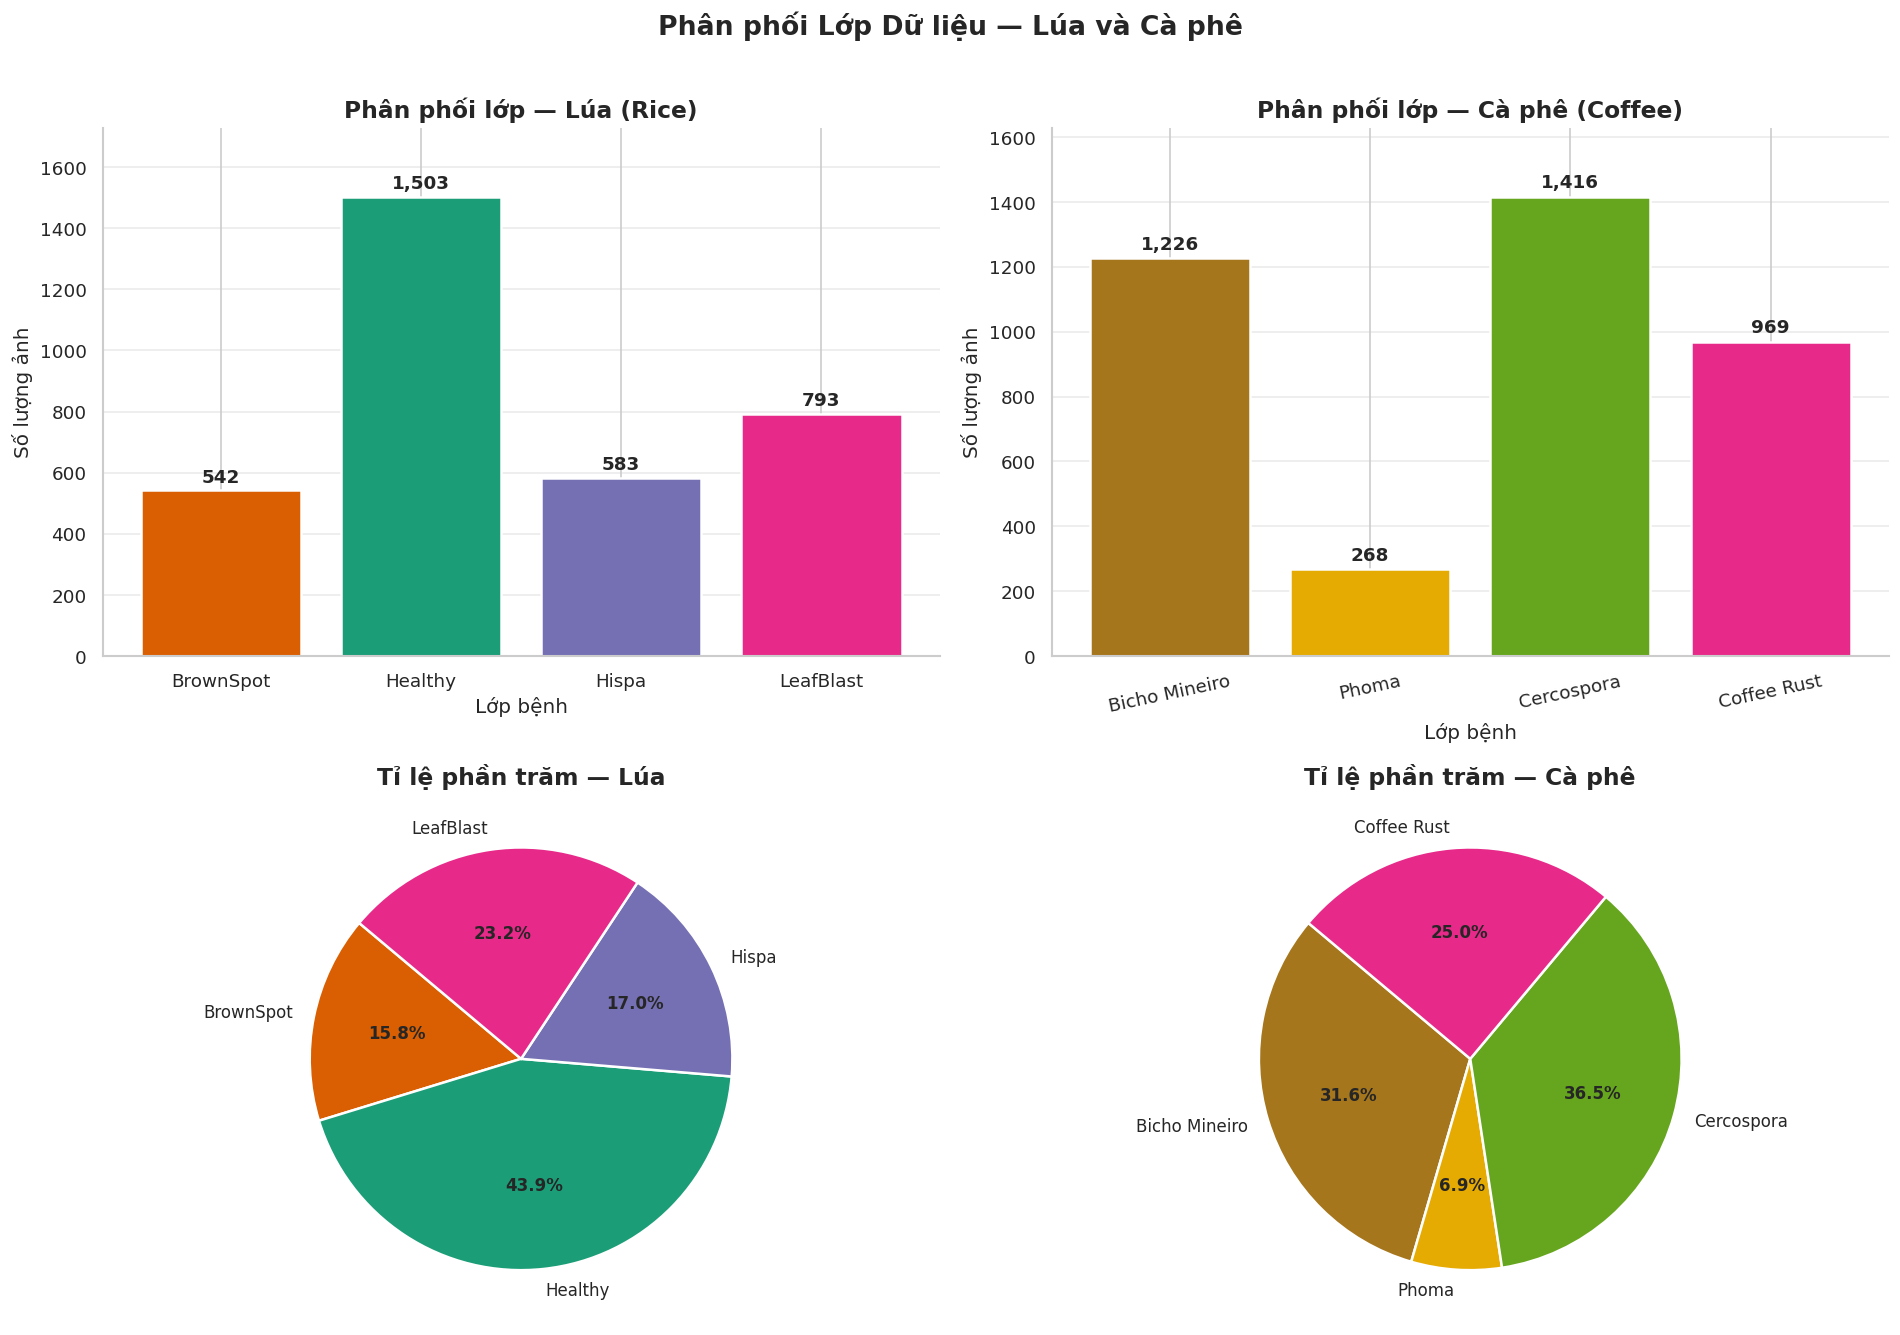

Lúa: IR = 2.77x | CV = 52.1% | majority=Healthy (1,503) | minority=BrownSpot (542)
Cà phê: IR = 5.28x | CV = 51.8% | majority=Cercospora (1,416) | minority=Phoma (268)


In [14]:
# ============================================================
# Class Distribution — Bar Charts & Pie Charts
# ============================================================
rice_counts   = rice_df["label"].value_counts().reindex(RICE_CLASSES)
coffee_counts = coffee_df["label"].value_counts().reindex(COFFEE_CLASSES)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Phân phối Lớp Dữ liệu — Lúa và Cà phê",
             fontsize=16, fontweight="bold", y=1.01)

# ── Rice bar ─────────────────────────────────────────────────
bars = axes[0, 0].bar(rice_counts.index, rice_counts.values,
                      color=PALETTE_RICE, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, rice_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, val + 15,
                    f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0, 0].set_title("Phân phối lớp — Lúa (Rice)")
axes[0, 0].set_xlabel("Lớp bệnh")
axes[0, 0].set_ylabel("Số lượng ảnh")
axes[0, 0].set_ylim(0, rice_counts.max() * 1.15)
axes[0, 0].yaxis.grid(True, alpha=0.4, zorder=0)

# ── Coffee bar ───────────────────────────────────────────────
bars = axes[0, 1].bar(coffee_counts.index, coffee_counts.values,
                      color=PALETTE_COFFEE, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, coffee_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, val + 15,
                    f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0, 1].set_title("Phân phối lớp — Cà phê (Coffee)")
axes[0, 1].set_xlabel("Lớp bệnh")
axes[0, 1].set_ylabel("Số lượng ảnh")
axes[0, 1].tick_params(axis="x", rotation=12)
axes[0, 1].set_ylim(0, coffee_counts.max() * 1.15)
axes[0, 1].yaxis.grid(True, alpha=0.4, zorder=0)

# ── Rice pie ─────────────────────────────────────────────────
_, _, autotexts = axes[1, 0].pie(
    rice_counts.values, labels=rice_counts.index,
    colors=PALETTE_RICE, autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1, 0].set_title("Tỉ lệ phần trăm — Lúa")

# ── Coffee pie ───────────────────────────────────────────────
_, _, autotexts = axes[1, 1].pie(
    coffee_counts.values, labels=coffee_counts.index,
    colors=PALETTE_COFFEE, autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1, 1].set_title("Tỉ lệ phần trăm — Cà phê")

plt.tight_layout()
plt.show()

for domain, counts in [("Lúa", rice_counts), ("Cà phê", coffee_counts)]:
    ir = counts.max() / counts.min()
    cv = counts.std() / counts.mean() * 100
    print(f"{domain}: IR = {ir:.2f}x | CV = {cv:.1f}% "
          f"| majority={counts.idxmax()} ({counts.max():,}) "
          f"| minority={counts.idxmin()} ({counts.min():,})")

---
<a id="sec4"></a>
## 4. Phân tích Kích thước và Tỉ lệ Ảnh

Sự đa dạng về kích thước ảnh là một thách thức trực tiếp trong quá trình huấn luyện, vì các mô hình deep learning yêu cầu đầu vào có kích thước cố định. Việc resize không phù hợp có thể dẫn đến:

- **Mất thông tin chi tiết bệnh:** Khi resize từ ảnh rất lớn (ví dụ 3000×3000 px) xuống 224×224 px, các vùng bệnh nhỏ có thể bị thu nhỏ đến mức không phân biệt được.
- **Méo tỉ lệ (aspect ratio distortion):** Resize về ảnh vuông mà không padding có thể kéo dạt hình thái lá, ảnh hưởng đến đặc trưng hình dạng.

**Tỉ lệ khung hình (Aspect Ratio)** được định nghĩa là $AR = W/H$. Giá trị $AR = 1$ ứng với ảnh vuông, $AR > 1$ là ảnh ngang (landscape), $AR < 1$ là ảnh dọc (portrait).

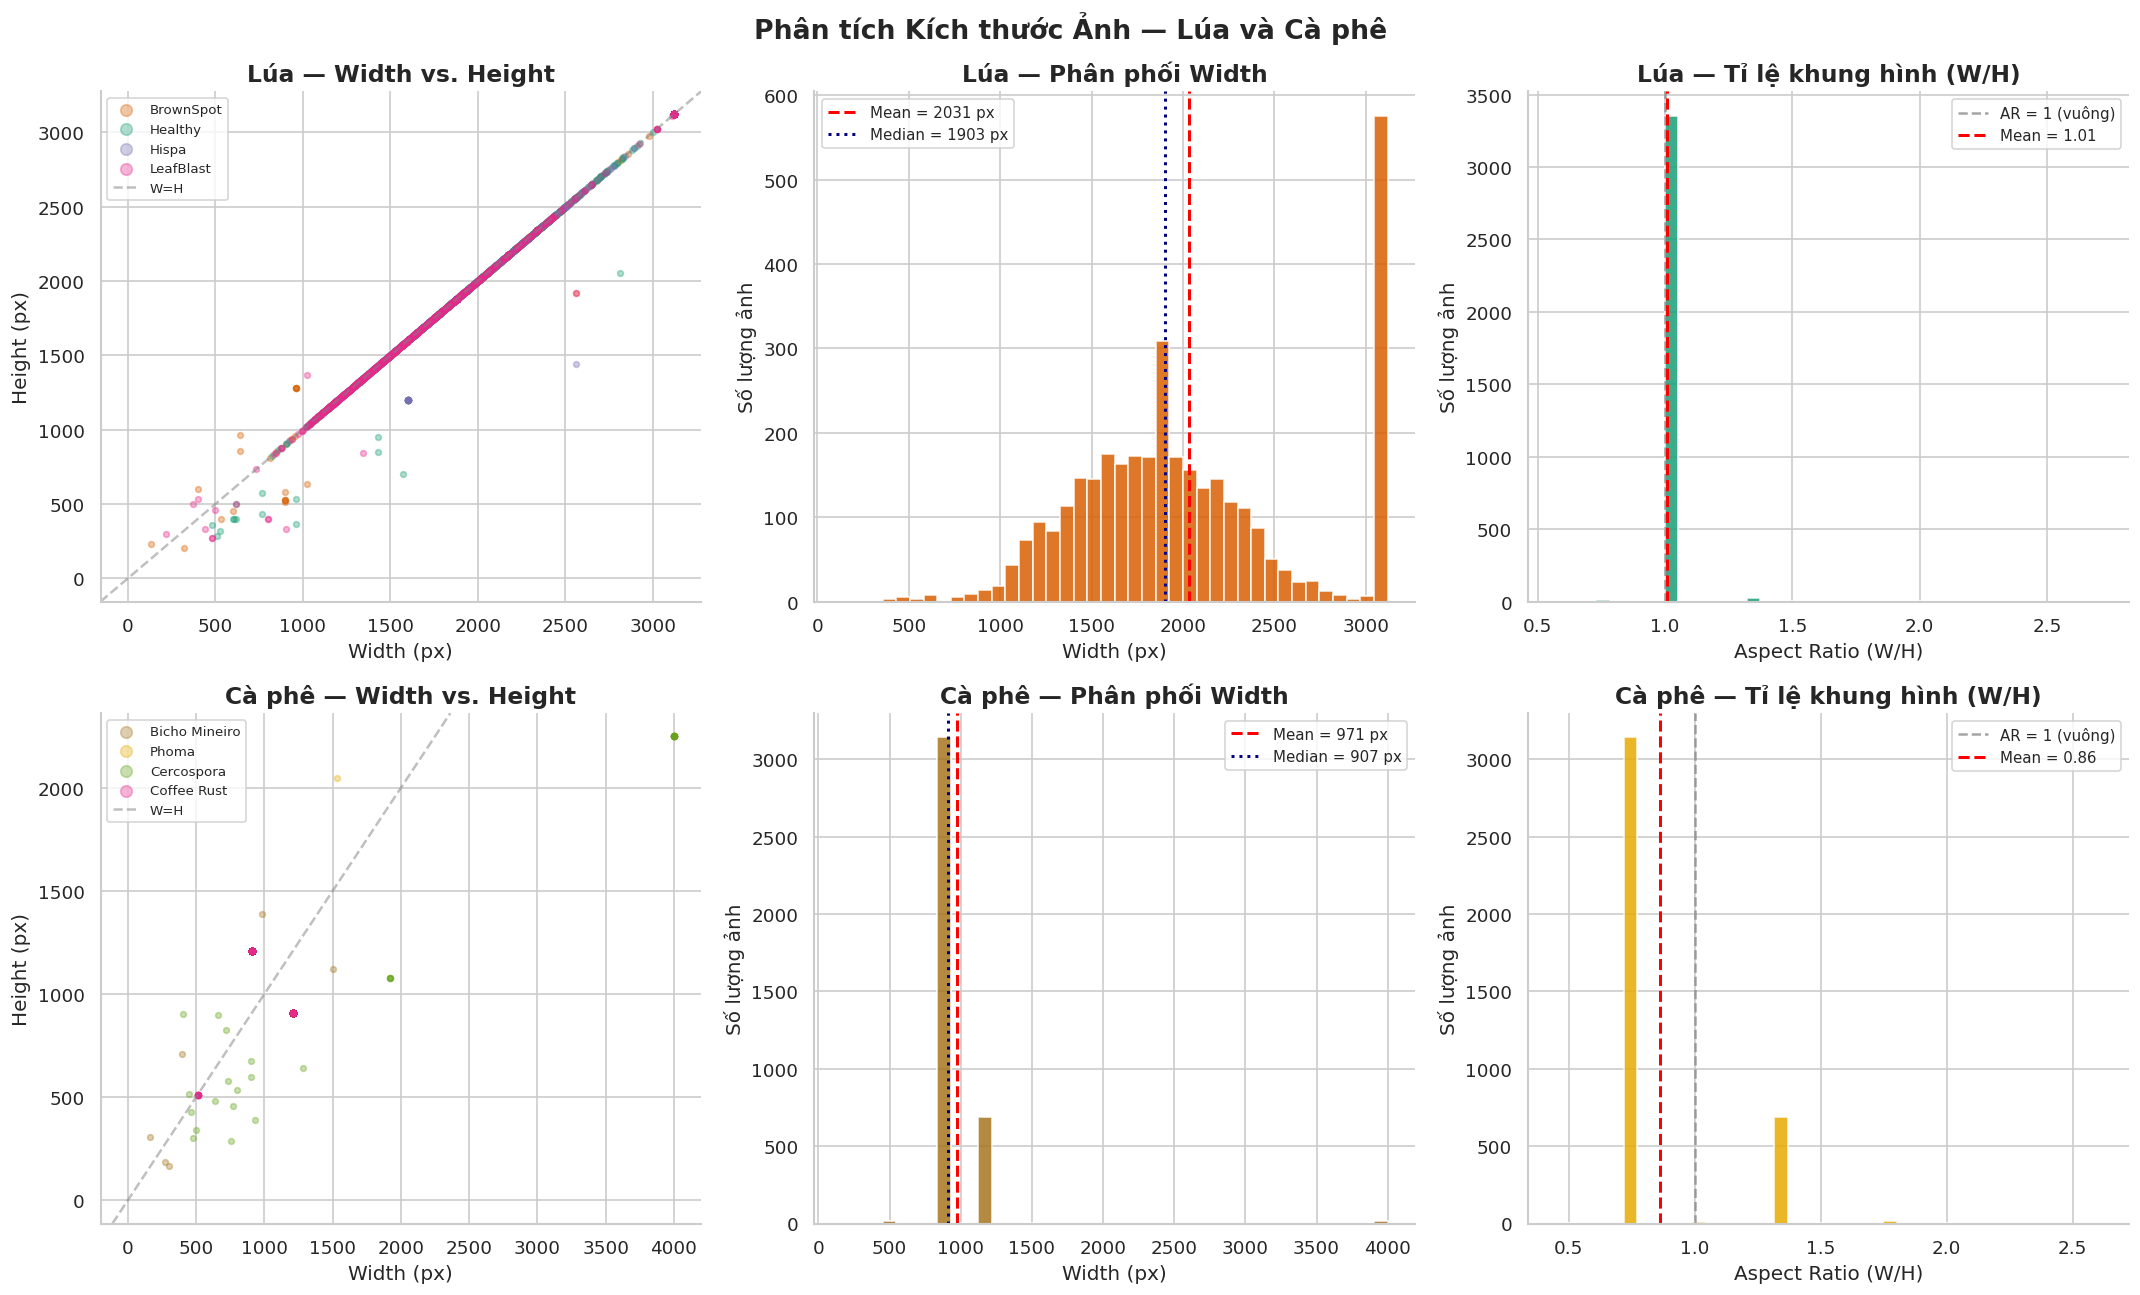

Lúa: width=[132, 3120] px | height=[206, 3120] px | AR=[0.57, 2.71]
Cà phê: width=[163, 4000] px | height=[168, 2250] px | AR=[0.45, 2.61]


In [15]:
# ============================================================
# Image Dimension Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Phân tích Kích thước Ảnh — Lúa và Cà phê",
             fontsize=16, fontweight="bold")

datasets = [
    ("Lúa",    rice_df,   RICE_CLASSES,   PALETTE_RICE,   axes[0]),
    ("Cà phê", coffee_df, COFFEE_CLASSES, PALETTE_COFFEE, axes[1]),
]

for domain, df, classes, palette, axrow in datasets:
    for cls, color in zip(classes, palette):
        mask = df["label"] == cls
        axrow[0].scatter(df[mask]["width"], df[mask]["height"],
                         c=color, alpha=0.35, s=12, label=cls)
    axrow[0].axline((0, 0), slope=1, color="gray", ls="--", alpha=0.5, label="W=H")
    axrow[0].set_title(f"{domain} — Width vs. Height")
    axrow[0].set_xlabel("Width (px)")
    axrow[0].set_ylabel("Height (px)")
    axrow[0].legend(fontsize=8, markerscale=2)

    axrow[1].hist(df["width"], bins=40, color=palette[0], edgecolor="white", alpha=0.85)
    axrow[1].axvline(df["width"].mean(), color="red", ls="--", lw=1.8,
                     label=f"Mean = {df['width'].mean():.0f} px")
    axrow[1].axvline(df["width"].median(), color="navy", ls=":", lw=1.8,
                     label=f"Median = {df['width'].median():.0f} px")
    axrow[1].set_title(f"{domain} — Phân phối Width")
    axrow[1].set_xlabel("Width (px)")
    axrow[1].set_ylabel("Số lượng ảnh")
    axrow[1].legend(fontsize=9)

    axrow[2].hist(df["aspect_ratio"], bins=40, color=palette[1], edgecolor="white", alpha=0.85)
    axrow[2].axvline(1.0, color="gray", ls="--", lw=1.5, alpha=0.7, label="AR = 1 (vuông)")
    axrow[2].axvline(df["aspect_ratio"].mean(), color="red", ls="--", lw=1.8,
                     label=f"Mean = {df['aspect_ratio'].mean():.2f}")
    axrow[2].set_title(f"{domain} — Tỉ lệ khung hình (W/H)")
    axrow[2].set_xlabel("Aspect Ratio (W/H)")
    axrow[2].set_ylabel("Số lượng ảnh")
    axrow[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

for domain, df in [("Lúa", rice_df), ("Cà phê", coffee_df)]:
    print(f"{domain}: width=[{df['width'].min()}, {df['width'].max()}] px | "
          f"height=[{df['height'].min()}, {df['height'].max()}] px | "
          f"AR=[{df['aspect_ratio'].min():.2f}, {df['aspect_ratio'].max():.2f}]")

---
<a id="sec5"></a>
## 5. Phân tích Độ sáng và Kênh màu RGB

### 5.1 Lý thuyết: Độ sáng Cảm nhận (Perceptual Luminance)

Độ sáng cảm nhận của một điểm ảnh RGB không phải là trung bình đơn giản của ba kênh màu, mà được tính theo công thức chuẩn ITU-R BT.601 phản ánh độ nhạy cảm của mắt người:

$$L(i, j) = 0.299 \cdot R(i, j) + 0.587 \cdot G(i, j) + 0.114 \cdot B(i, j)$$

Độ sáng trung bình của một ảnh $I$ có kích thước $H \times W$ được tính là:

$$\mu_L(I) = \frac{1}{H \cdot W} \sum_{i=1}^{H} \sum_{j=1}^{W} L(i, j)$$

### 5.2 Lý thuyết: Độ tương phản (Local Contrast)

Độ tương phản được ước lượng bằng độ lệch chuẩn của kênh độ sáng:

$$\sigma_L(I) = \sqrt{\frac{1}{H \cdot W} \sum_{i=1}^{H} \sum_{j=1}^{W} \left(L(i,j) - \mu_L\right)^2}$$

Ảnh có $\sigma_L$ thấp cho thấy sự đồng đều về độ sáng, trong khi $\sigma_L$ cao chỉ ra sự đa dạng về tông màu — thường gặp hơn trong ảnh thực địa.

### 5.3 Ý nghĩa đối với quá trình tiền xử lý

Phân phối độ sáng và màu sắc khác nhau giữa các lớp bệnh gợi ý rằng:
- Cần áp dụng **chuẩn hóa theo kênh** (per-channel normalization) dựa trên thống kê của tập huấn luyện, không phải ImageNet.
- **Augmentation liên quan đến độ sáng** (ColorJitter, RandomBrightnessContrast) là cần thiết để tăng tính bền vững của mô hình trước biến thiên ánh sáng thực địa.

In [16]:
# ============================================================
# Sample Brightness & Color Channel Statistics
# Uses visualize.sample_color_stats() — samples 50 images/class
# ============================================================
N_SAMPLE = 50

print("Sampling rice images for color analysis...")
rice_color = sample_color_stats(RICE_DIR, RICE_CLASSES, RICE_FOLDER, n=N_SAMPLE)
print("Sampling coffee images for color analysis...")
coffee_color = sample_color_stats(COFFEE_DIR, COFFEE_CLASSES, COFFEE_FOLDER, n=N_SAMPLE)
print(f"Done. Rice: {len(rice_color)} | Coffee: {len(coffee_color)} samples")

print()
print("Brightness statistics by class (Lúa):")
print(rice_color.groupby("class")[["brightness", "contrast"]].agg(["mean", "std"]).round(2).to_string())
print()
print("Brightness statistics by class (Cà phê):")
print(coffee_color.groupby("class")[["brightness", "contrast"]].agg(["mean", "std"]).round(2).to_string())

Sampling rice images for color analysis...
Sampling coffee images for color analysis...
Done. Rice: 200 | Coffee: 200 samples

Brightness statistics by class (Lúa):
          brightness        contrast       
                mean    std     mean    std
class                                      
BrownSpot     201.26  17.55    44.85   9.45
Healthy       201.44  11.86    50.20   9.20
Hispa         200.37  20.24    43.83  10.20
LeafBlast     194.92  21.70    45.02  12.70

Brightness statistics by class (Cà phê):
              brightness        contrast      
                    mean    std     mean   std
class                                         
Bicho Mineiro     127.88  11.84    52.62  6.25
Cercospora        128.14  10.97    51.71  4.63
Coffee Rust       119.18  13.52    56.27  5.61
Phoma             117.47   8.25    57.26  4.57


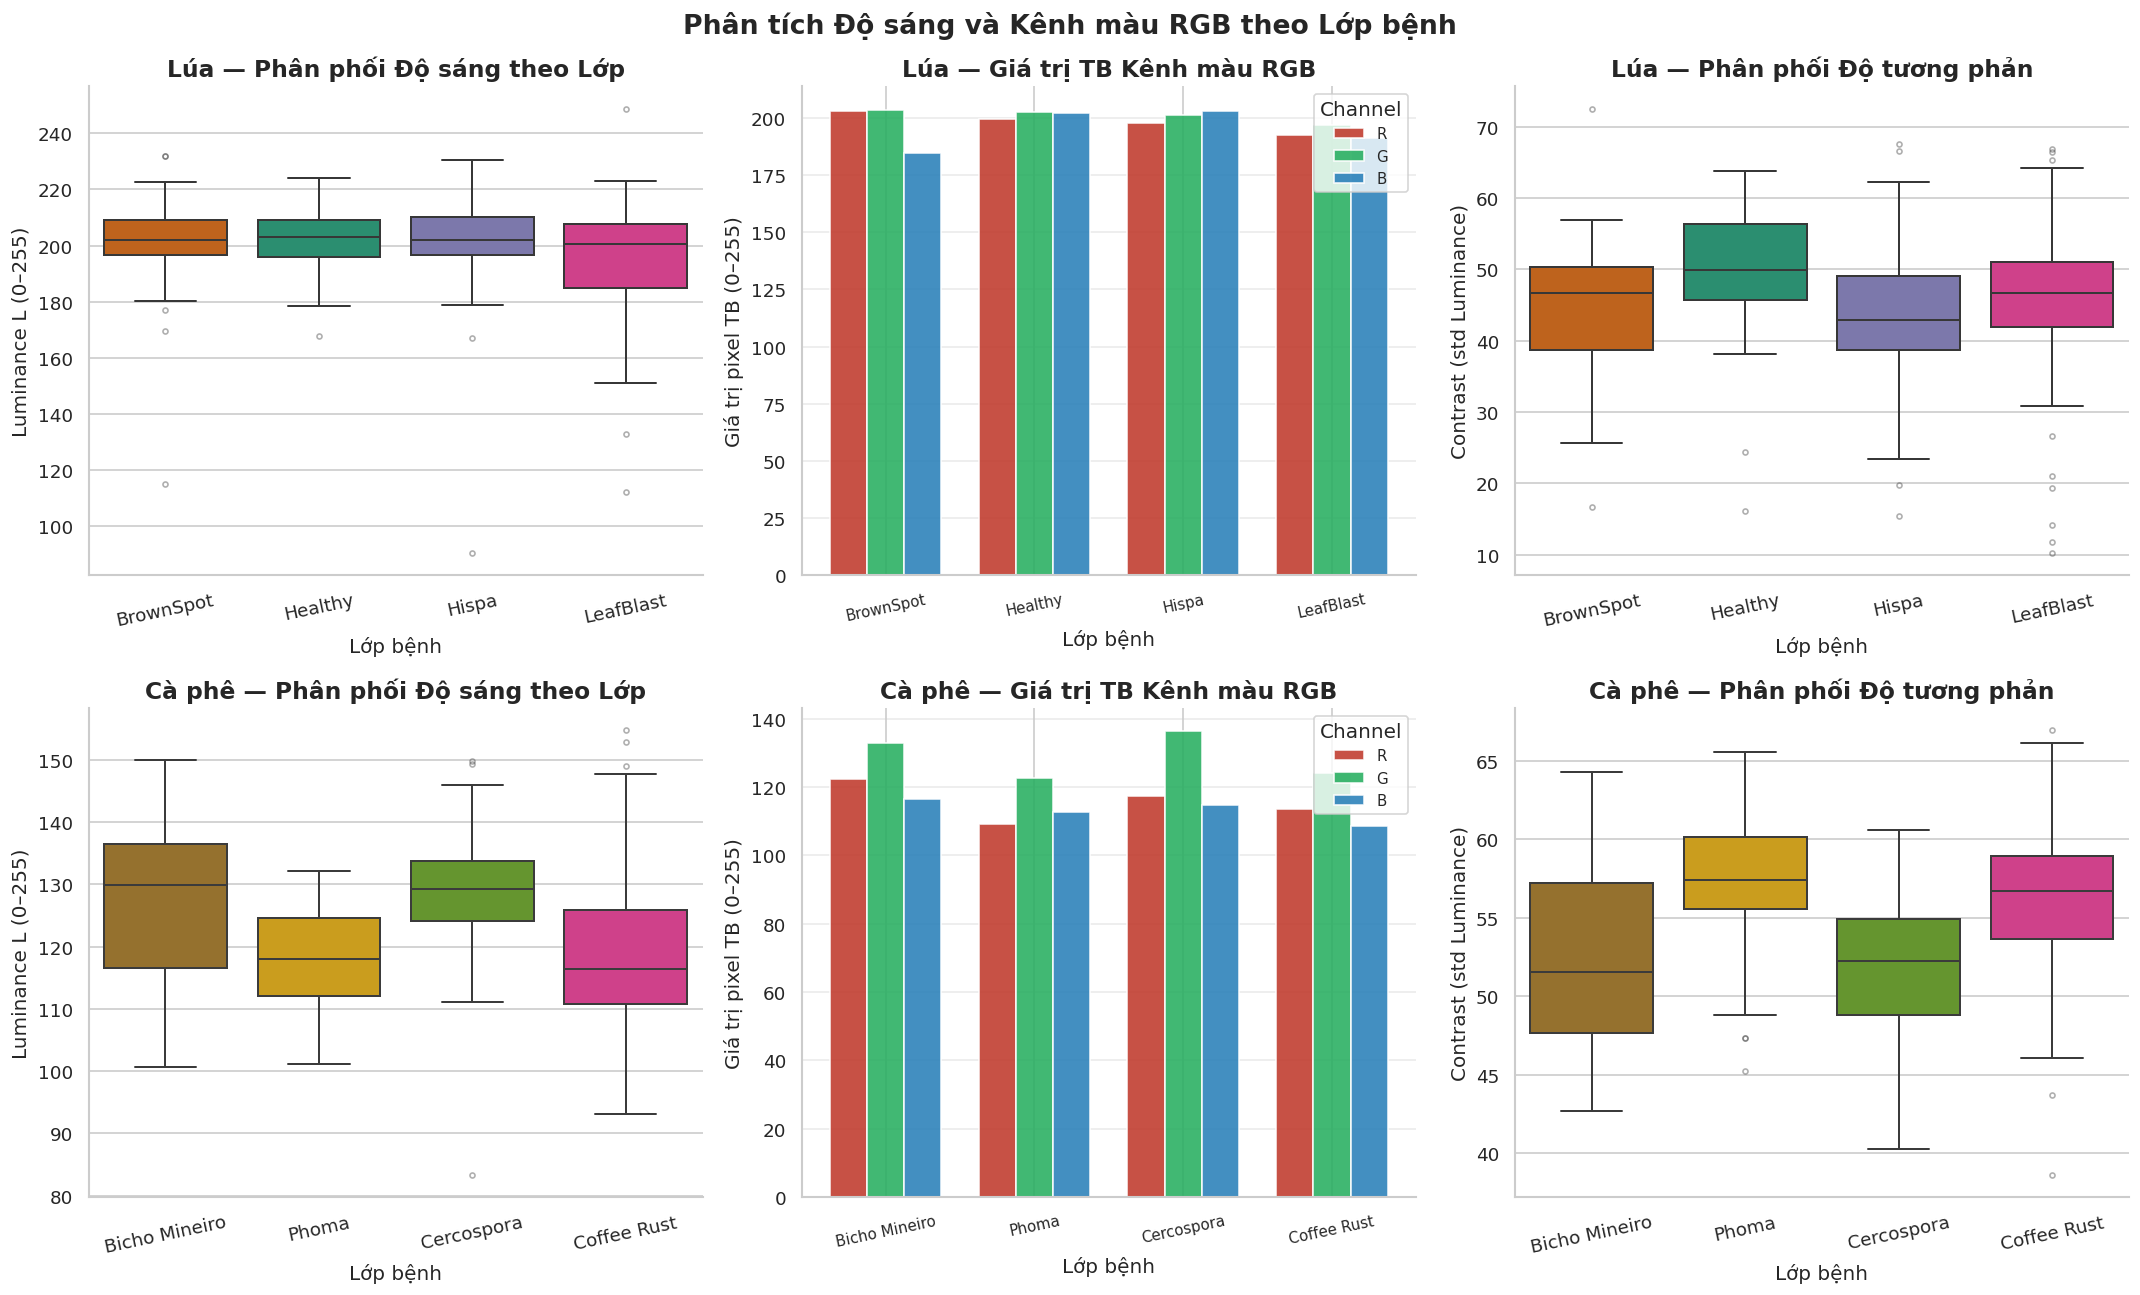

In [17]:
# ============================================================
# Brightness & RGB Channel Visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Phân tích Độ sáng và Kênh màu RGB theo Lớp bệnh",
             fontsize=16, fontweight="bold")

datasets = [
    ("Lúa",    rice_color,   RICE_CLASSES,   PALETTE_RICE,   axes[0]),
    ("Cà phê", coffee_color, COFFEE_CLASSES, PALETTE_COFFEE, axes[1]),
]

for domain, color_df, classes, palette, axrow in datasets:
    sns.boxplot(data=color_df, x="class", y="brightness", order=classes,
                palette=palette, ax=axrow[0], linewidth=1.2,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    axrow[0].set_title(f"{domain} — Phân phối Độ sáng theo Lớp")
    axrow[0].set_xlabel("Lớp bệnh")
    axrow[0].set_ylabel("Luminance L (0–255)")
    axrow[0].tick_params(axis="x", rotation=12)

    rgb_means = (color_df.groupby("class")[["r_mean", "g_mean", "b_mean"]]
                 .mean().reindex(classes))
    x, w = np.arange(len(classes)), 0.25
    axrow[1].bar(x - w, rgb_means["r_mean"], width=w, color="#C0392B", label="R", alpha=0.88, edgecolor="white")
    axrow[1].bar(x,     rgb_means["g_mean"], width=w, color="#27AE60", label="G", alpha=0.88, edgecolor="white")
    axrow[1].bar(x + w, rgb_means["b_mean"], width=w, color="#2980B9", label="B", alpha=0.88, edgecolor="white")
    axrow[1].set_xticks(x)
    axrow[1].set_xticklabels(classes, rotation=12, fontsize=9)
    axrow[1].set_title(f"{domain} — Giá trị TB Kênh màu RGB")
    axrow[1].set_xlabel("Lớp bệnh")
    axrow[1].set_ylabel("Giá trị pixel TB (0–255)")
    axrow[1].legend(title="Channel", fontsize=9)
    axrow[1].yaxis.grid(True, alpha=0.4)

    sns.boxplot(data=color_df, x="class", y="contrast", order=classes,
                palette=palette, ax=axrow[2], linewidth=1.2,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    axrow[2].set_title(f"{domain} — Phân phối Độ tương phản")
    axrow[2].set_xlabel("Lớp bệnh")
    axrow[2].set_ylabel("Contrast (std Luminance)")
    axrow[2].tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()

---
<a id="sec6"></a>
## 6. Trực quan hóa Mẫu Bệnh

Việc quan sát trực tiếp các mẫu ảnh từ mỗi lớp bệnh giúp nhận diện những đặc điểm ngoại quan đặc trưng, đồng thời phát hiện các trường hợp gây khó khăn cho mô hình (ảnh mờ, nhiều lá chồng nhau, ảnh chụp xa, bệnh ở giai đoạn sớm). Mỗi hàng dưới đây thể hiện bốn mẫu được chọn ngẫu nhiên từ mỗi lớp bệnh.

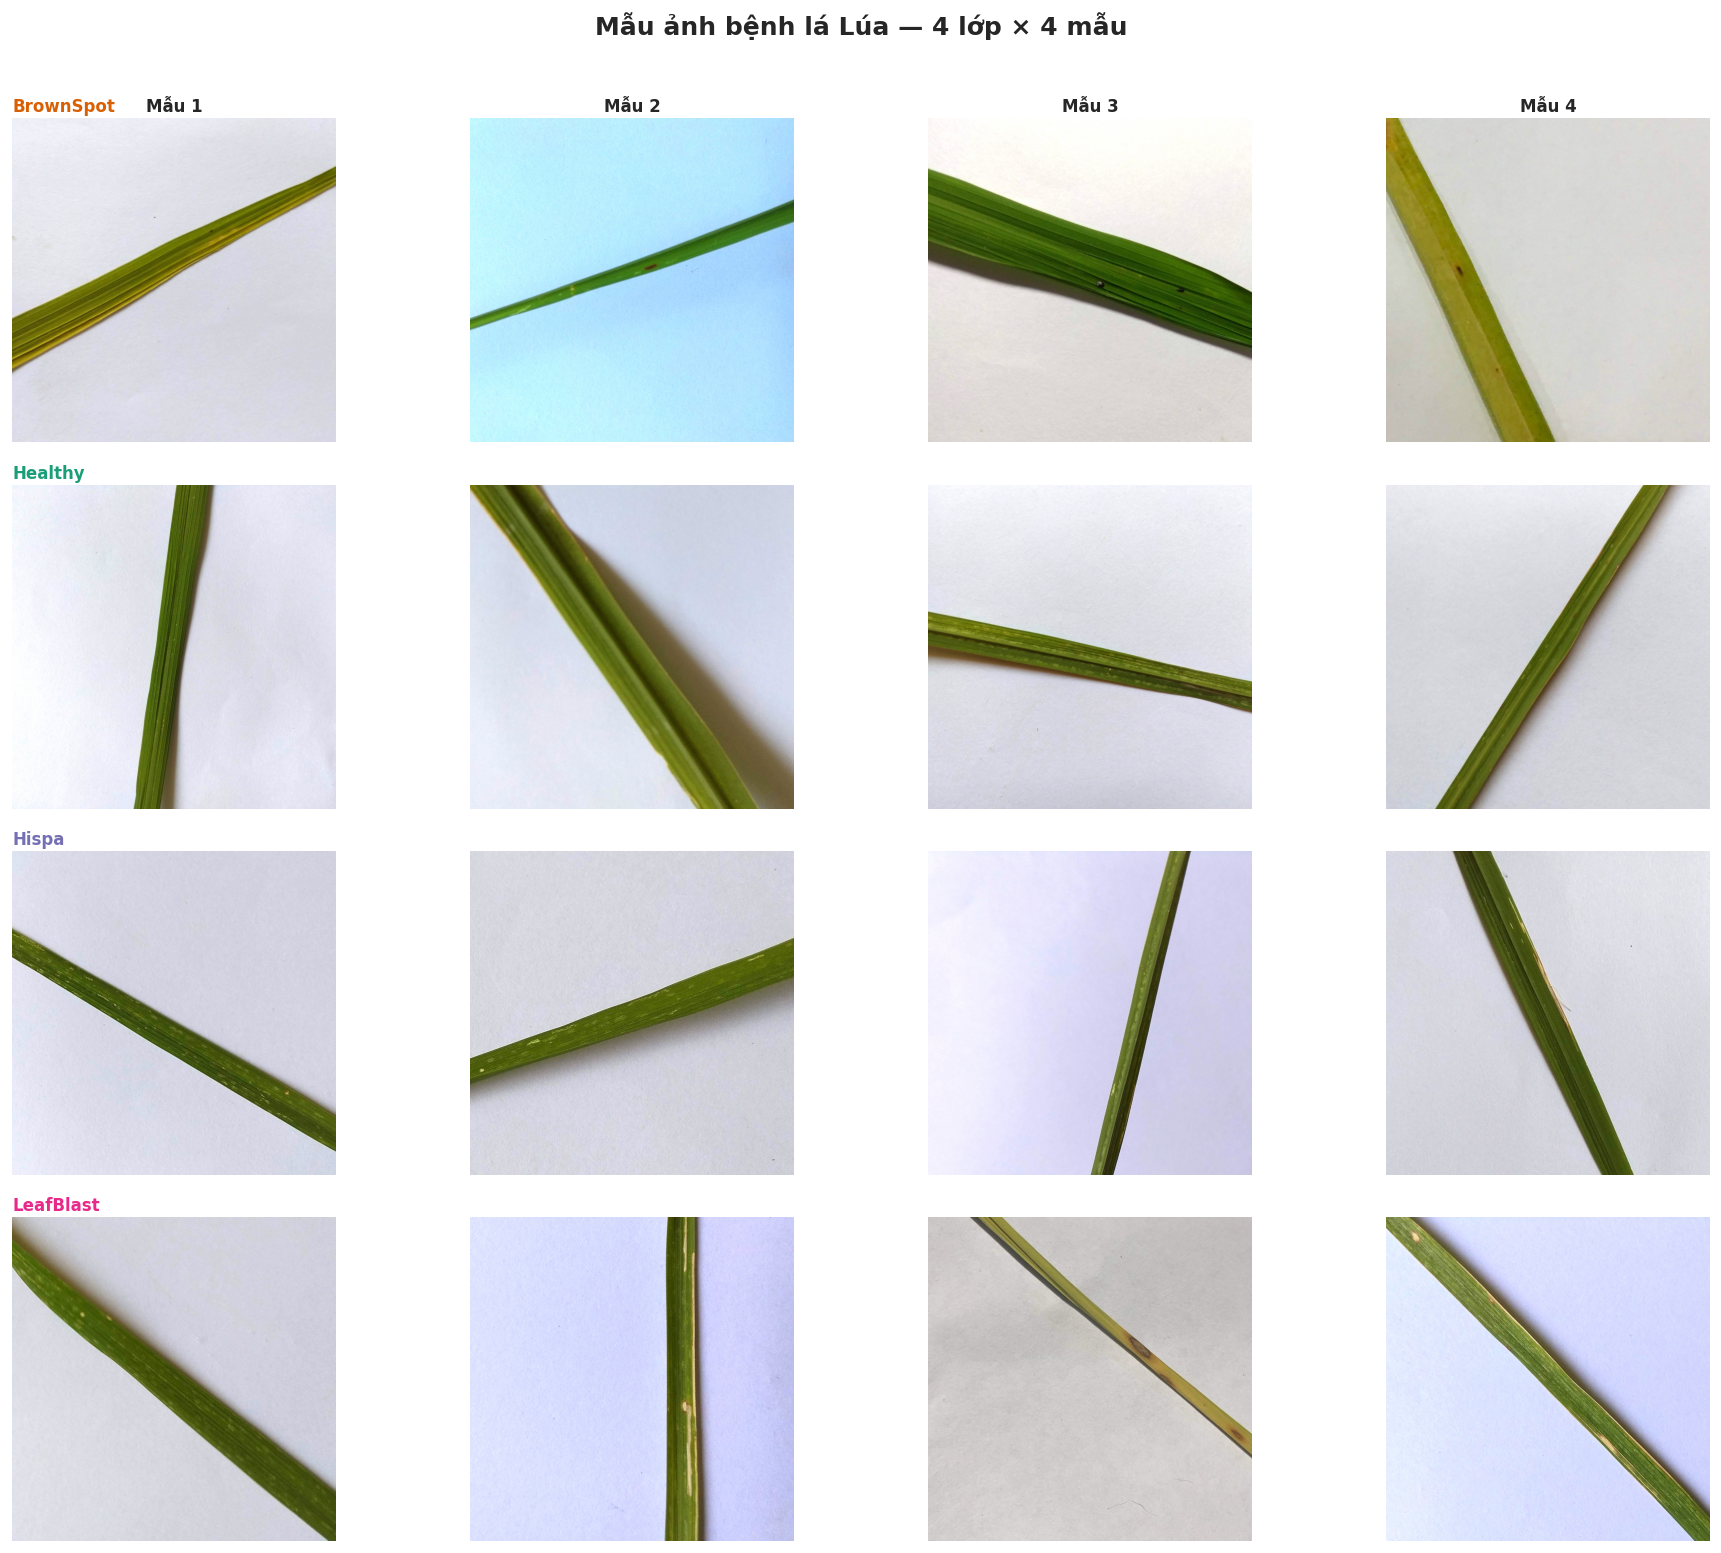

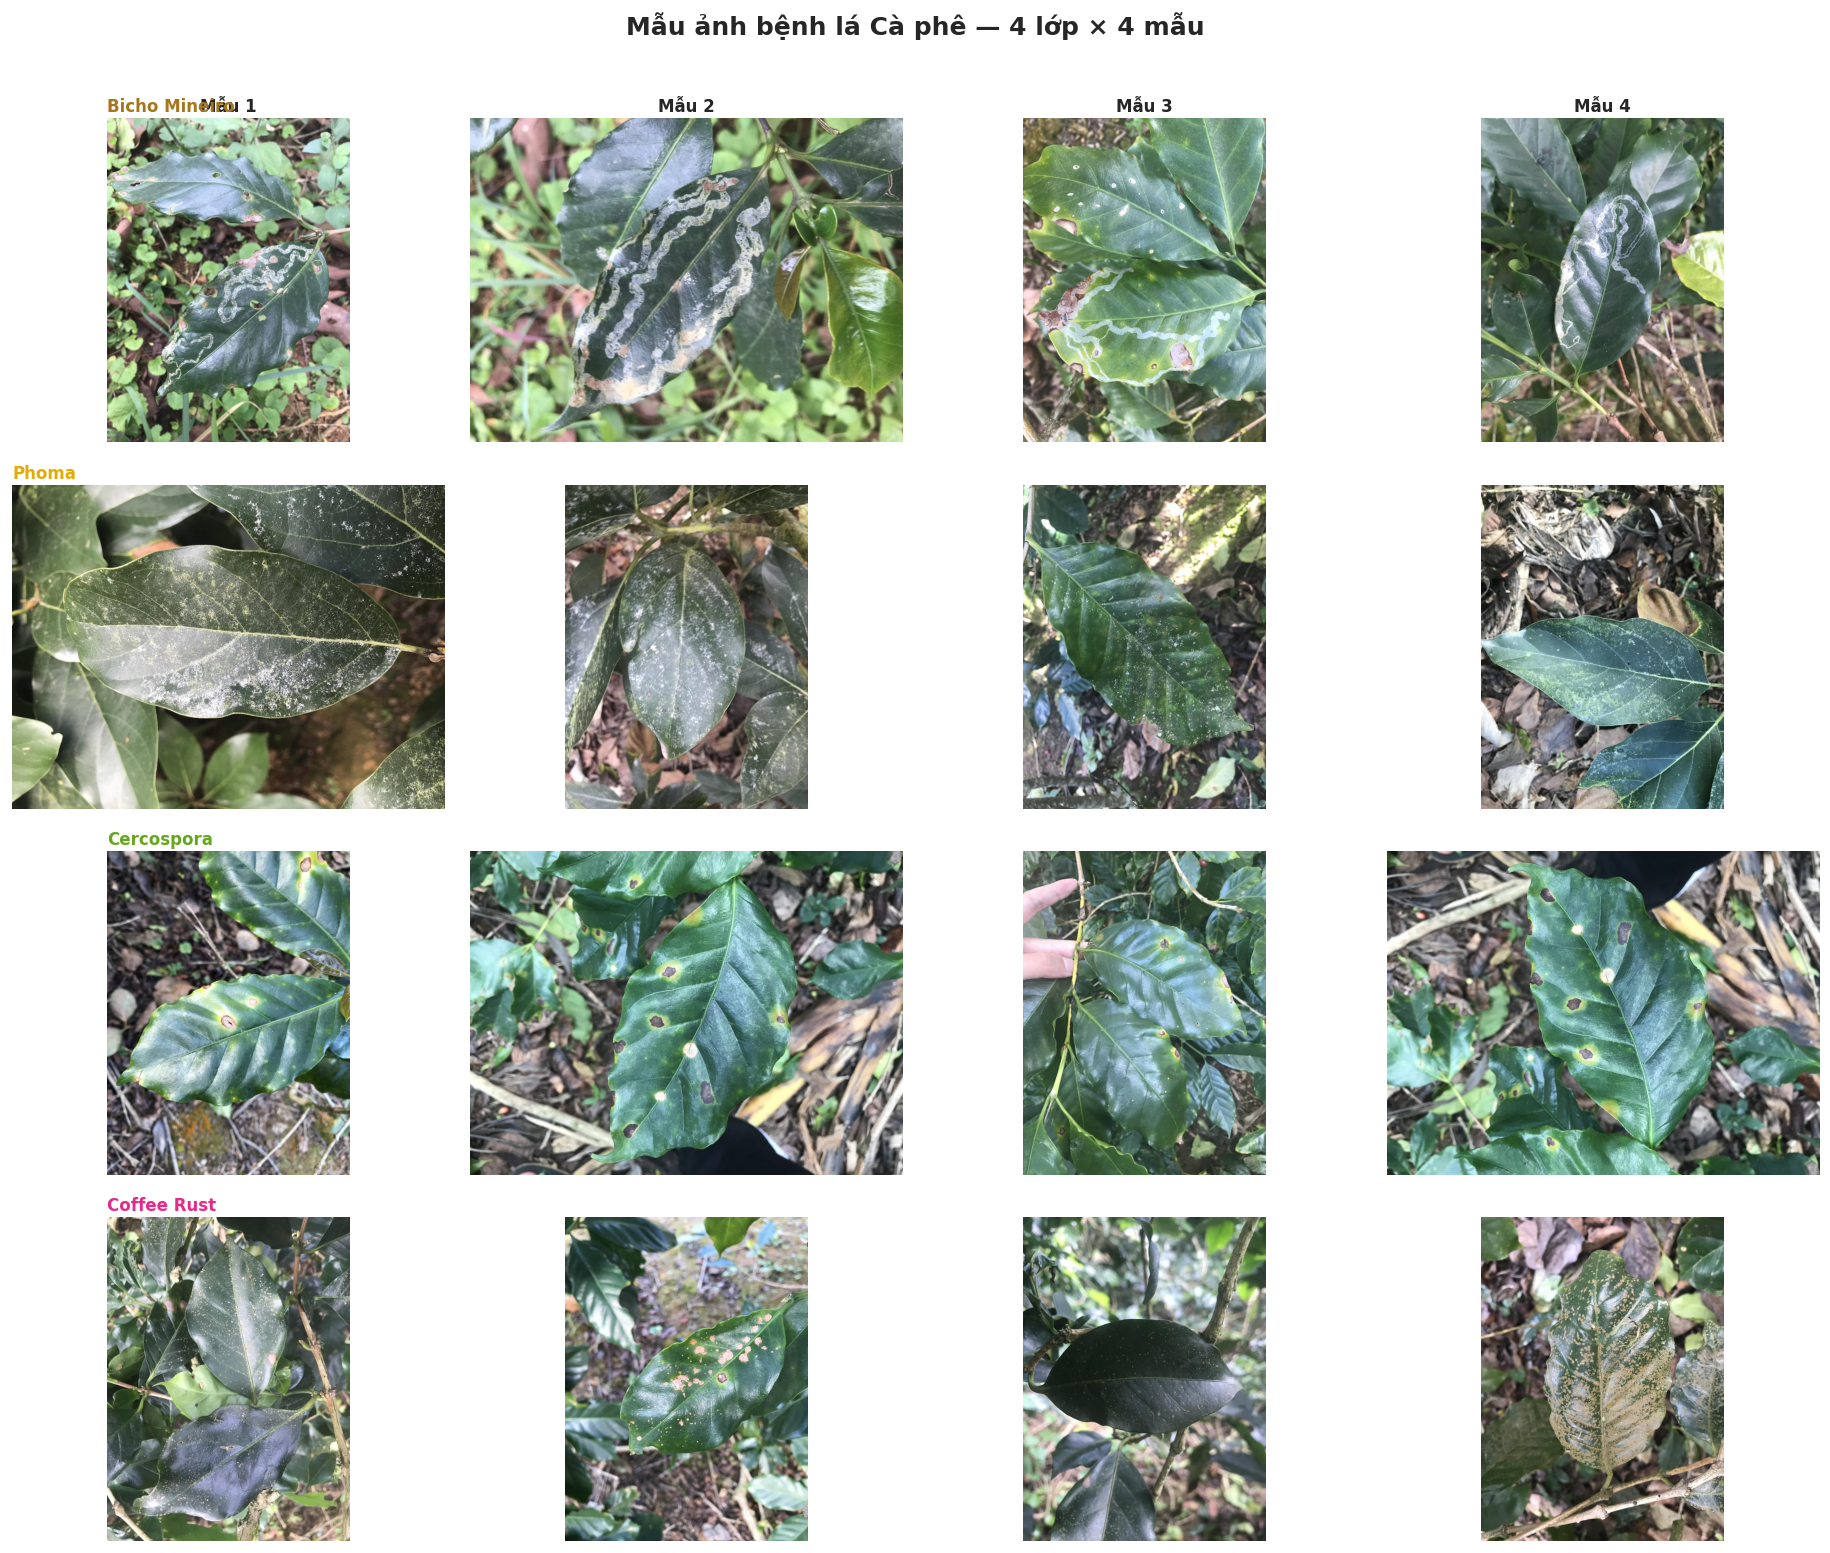

In [18]:
# ============================================================
# Sample Image Grid Visualization
# Uses visualize.show_sample_grid()
# ============================================================
show_sample_grid(RICE_DIR,   RICE_CLASSES,   RICE_FOLDER,   PALETTE_RICE,
                 "Mẫu ảnh bệnh lá Lúa — 4 lớp × 4 mẫu")
show_sample_grid(COFFEE_DIR, COFFEE_CLASSES, COFFEE_FOLDER, PALETTE_COFFEE,
                 "Mẫu ảnh bệnh lá Cà phê — 4 lớp × 4 mẫu")

---
<a id="sec7"></a>
## 7. Phân tích Annotation COCO

Bộ dữ liệu được gán nhãn theo chuẩn COCO với các **polygon segmentation** bao quanh từng vùng bệnh. Phân tích annotation giúp trả lời các câu hỏi quan trọng:

- Mỗi ảnh trung bình có bao nhiêu vùng bệnh được đánh dấu?
- Các vùng bệnh chiếm bao nhiêu phần trăm diện tích ảnh?
- Có sự khác biệt nào về kích thước vùng bệnh giữa các lớp không?

Những thông tin này có ảnh hưởng trực tiếp đến quyết định:
1. Sử dụng bounding box crop hay ảnh toàn phần làm đầu vào mô hình.
2. Thiết kế chiến lược augmentation phù hợp với scale của vùng bệnh.

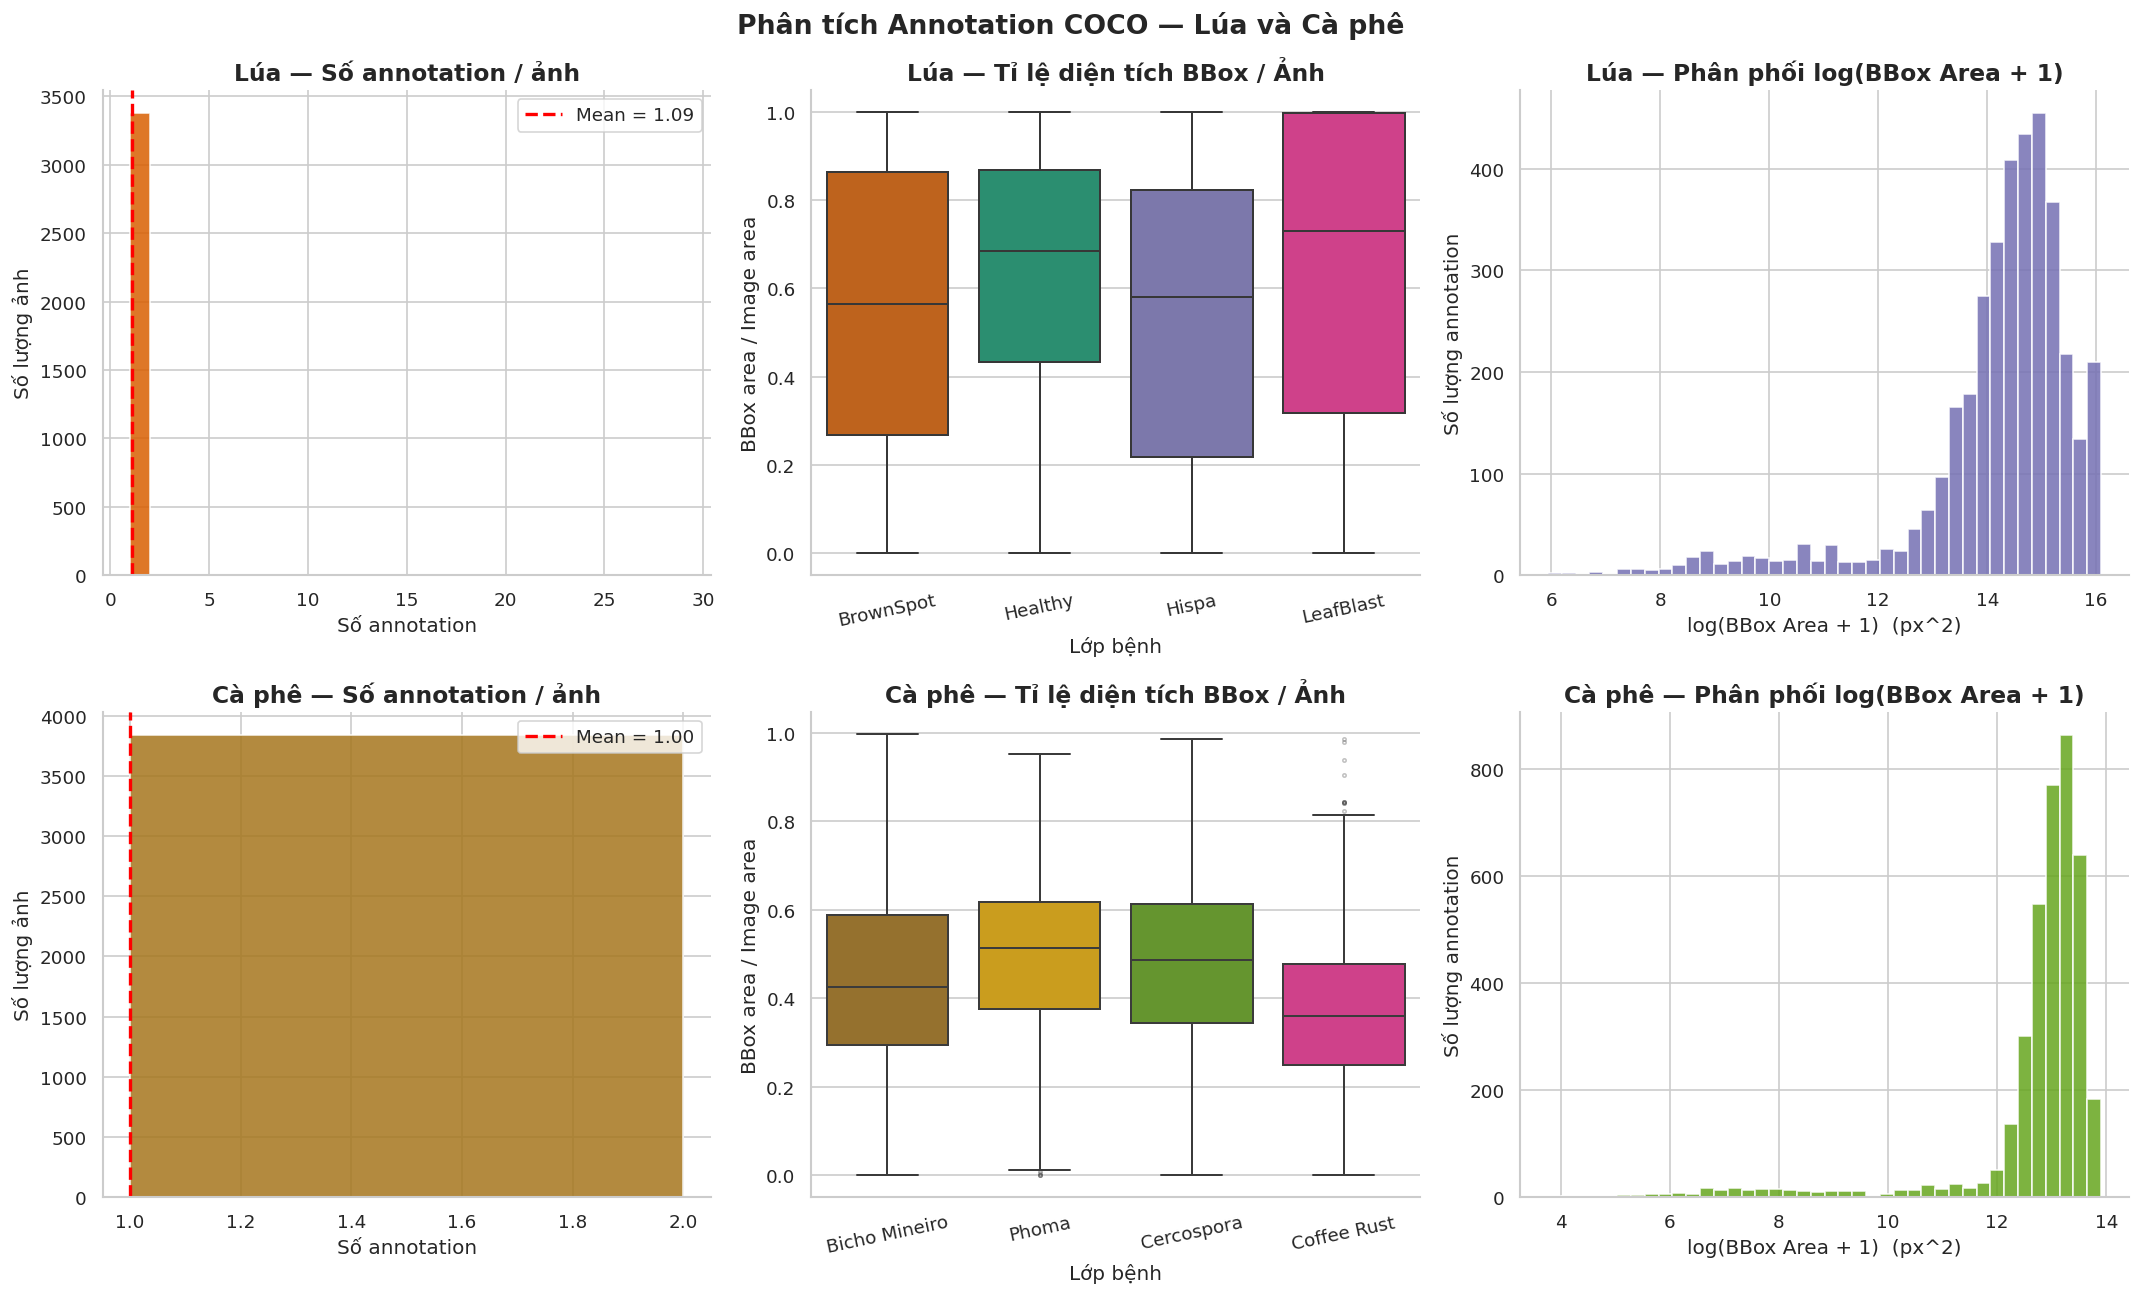

Lúa: ann/img — min=1, max=28, mean=1.09
Cà phê: ann/img — min=1, max=1, mean=1.00


In [19]:
# ============================================================
# COCO Annotation Analysis
# ============================================================
rice_ann_full   = rice_ann_df.merge(
    rice_df[["image_id", "width", "height"]], on="image_id", how="left")
coffee_ann_full = coffee_ann_df.merge(
    coffee_df[["image_id", "width", "height"]], on="image_id", how="left")

rice_ann_full["rel_area"]   = (rice_ann_full["bbox_area"]
                                / (rice_ann_full["width"] * rice_ann_full["height"])).clip(upper=1)
coffee_ann_full["rel_area"] = (coffee_ann_full["bbox_area"]
                                / (coffee_ann_full["width"] * coffee_ann_full["height"])).clip(upper=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Phân tích Annotation COCO — Lúa và Cà phê",
             fontsize=16, fontweight="bold")

datasets = [
    ("Lúa",    rice_ann_df,   rice_ann_full,   RICE_CLASSES,   PALETTE_RICE,   axes[0]),
    ("Cà phê", coffee_ann_df, coffee_ann_full, COFFEE_CLASSES, PALETTE_COFFEE, axes[1]),
]

for domain, ann_df, ann_full, classes, palette, axrow in datasets:
    apc = ann_df.groupby("image_id").size()
    axrow[0].hist(apc.values, bins=range(1, min(int(apc.max()) + 2, 30)),
                  color=palette[0], edgecolor="white", alpha=0.85)
    axrow[0].axvline(apc.mean(), color="red", ls="--", lw=2, label=f"Mean = {apc.mean():.2f}")
    axrow[0].set_title(f"{domain} — Số annotation / ảnh")
    axrow[0].set_xlabel("Số annotation")
    axrow[0].set_ylabel("Số lượng ảnh")
    axrow[0].legend()

    valid = ann_full[ann_full["class_name"].isin(classes)]
    order = [c for c in classes if c in valid["class_name"].values]
    pal   = [p for c, p in zip(classes, palette) if c in order]
    sns.boxplot(data=valid, x="class_name", y="rel_area", order=order,
                palette=pal, ax=axrow[1], linewidth=1.2,
                flierprops={"marker": "o", "markersize": 2, "alpha": 0.3})
    axrow[1].set_title(f"{domain} — Tỉ lệ diện tích BBox / Ảnh")
    axrow[1].set_xlabel("Lớp bệnh")
    axrow[1].set_ylabel("BBox area / Image area")
    axrow[1].tick_params(axis="x", rotation=12)

    axrow[2].hist(np.log1p(ann_full["bbox_area"].dropna()), bins=40,
                  color=palette[2], edgecolor="white", alpha=0.85)
    axrow[2].set_title(f"{domain} — Phân phối log(BBox Area + 1)")
    axrow[2].set_xlabel("log(BBox Area + 1)  (px^2)")
    axrow[2].set_ylabel("Số lượng annotation")

plt.tight_layout()
plt.show()

for domain, ann_df in [("Lúa", rice_ann_df), ("Cà phê", coffee_ann_df)]:
    apc = ann_df.groupby("image_id").size()
    print(f"{domain}: ann/img — min={apc.min()}, max={apc.max()}, mean={apc.mean():.2f}")

---
<a id="sec8"></a>
## 8. Nhận diện Cặp Bệnh Dễ Nhầm lẫn

### 8.1 Lý thuyết: Phân tích Histogram màu

Histogram kênh màu là công cụ thống kê đơn giản nhưng hiệu quả để so sánh đặc trưng màu sắc toàn cục giữa các lớp. Với mỗi kênh $c \in \{R, G, B\}$, histogram chuẩn hóa được định nghĩa:

$$h_c(v) = \frac{1}{H \cdot W} \sum_{i,j} \mathbf{1}\left[I_c(i,j) = v\right], \quad v \in [0, 255]$$

Khoảng cách Bhattacharyya giữa hai phân phối $p$ và $q$ đo mức độ trùng lặp:

$$D_B(p, q) = -\ln \left( \sum_{v=0}^{255} \sqrt{p(v) \cdot q(v)} \right)$$

$D_B = 0$ nghĩa là hai phân phối giống hệt nhau; giá trị càng lớn, hai lớp càng dễ phân biệt.

### 8.2 Các cặp bệnh cần chú ý

**Lúa:** BrownSpot vs. LeafBlast — Cả hai tạo ra vết đốm màu nâu-vàng, đặc biệt khó phân biệt ở giai đoạn đầu.

**Cà phê:** Coffee Rust vs. Cercospora — Cả hai tạo ra đốm vàng trên mặt lá với màu sắc tương tự.

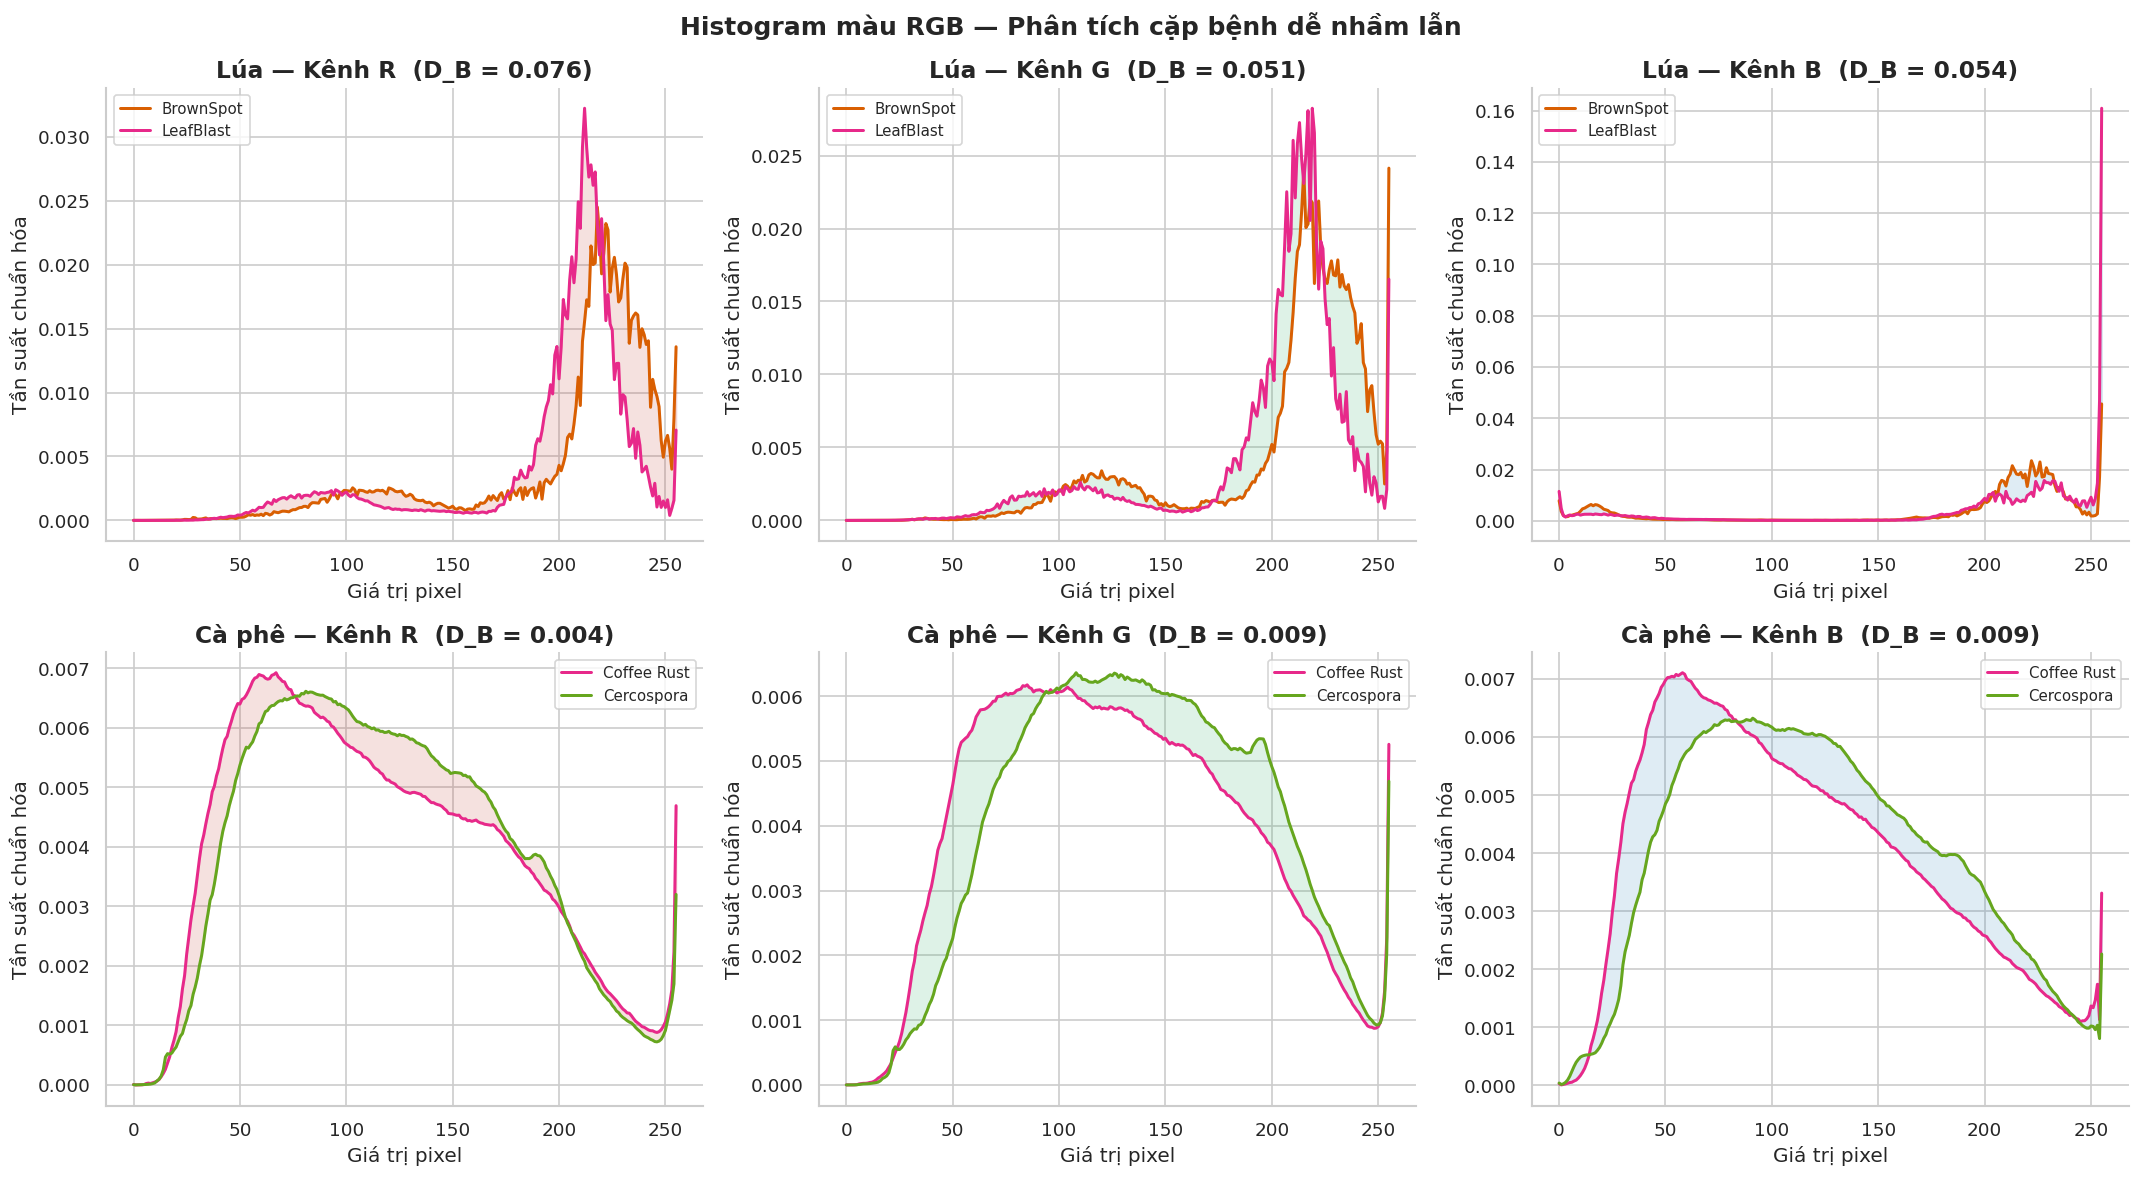

D_B gần 0: hai lớp có phân phối màu tương đồng → mô hình cần học đặc trưng texture.


In [20]:
# ============================================================
# Color Histogram Comparison — Confusable Disease Pairs
# Uses visualize.compute_mean_histogram()
# ============================================================
rice_hists = {
    cls: compute_mean_histogram(RICE_DIR, cls, RICE_FOLDER)
    for cls in ["BrownSpot", "LeafBlast"]
}
coffee_hists = {
    cls: compute_mean_histogram(COFFEE_DIR, cls, COFFEE_FOLDER)
    for cls in ["Coffee Rust", "Cercospora"]
}

bins = np.arange(256)
channel_colors = {"R": "#C0392B", "G": "#27AE60", "B": "#2980B9"}
rice_pair_colors   = {"BrownSpot": "#D95F02", "LeafBlast": "#E7298A"}
coffee_pair_colors = {"Coffee Rust": "#E7298A", "Cercospora": "#66A61E"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Histogram màu RGB — Phân tích cặp bệnh dễ nhầm lẫn",
             fontsize=15, fontweight="bold")

for col, ch in enumerate(["R", "G", "B"]):
    ch_color = channel_colors[ch]

    ax_r = axes[0, col]
    h_bs = rice_hists["BrownSpot"][ch]
    h_lb = rice_hists["LeafBlast"][ch]
    ax_r.plot(bins, h_bs, color=rice_pair_colors["BrownSpot"], lw=1.8, label="BrownSpot")
    ax_r.plot(bins, h_lb, color=rice_pair_colors["LeafBlast"],  lw=1.8, label="LeafBlast")
    ax_r.fill_between(bins, h_bs, h_lb, alpha=0.15, color=ch_color)
    bc = np.sum(np.sqrt(np.clip(h_bs * h_lb, 0, None)))
    ax_r.set_title(f"Lúa — Kênh {ch}  (D_B = {-np.log(bc + 1e-10):.3f})")
    ax_r.set_xlabel("Giá trị pixel")
    ax_r.set_ylabel("Tần suất chuẩn hóa")
    ax_r.legend(fontsize=9)

    ax_c = axes[1, col]
    h_cr = coffee_hists["Coffee Rust"][ch]
    h_ce = coffee_hists["Cercospora"][ch]
    ax_c.plot(bins, h_cr, color=coffee_pair_colors["Coffee Rust"], lw=1.8, label="Coffee Rust")
    ax_c.plot(bins, h_ce, color=coffee_pair_colors["Cercospora"],  lw=1.8, label="Cercospora")
    ax_c.fill_between(bins, h_cr, h_ce, alpha=0.15, color=ch_color)
    bc = np.sum(np.sqrt(np.clip(h_cr * h_ce, 0, None)))
    ax_c.set_title(f"Cà phê — Kênh {ch}  (D_B = {-np.log(bc + 1e-10):.3f})")
    ax_c.set_xlabel("Giá trị pixel")
    ax_c.set_ylabel("Tần suất chuẩn hóa")
    ax_c.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("D_B gần 0: hai lớp có phân phối màu tương đồng → mô hình cần học đặc trưng texture.")

---
<a id="sec9"></a>
## 9. Chỉ số Đánh giá — Macro F1-score

Dựa trên phân tích mất cân bằng lớp ở Phần 3, chúng ta xác nhận rằng **Macro F1-score** là chỉ số đánh giá phù hợp nhất cho bài toán này.

### 9.1 Định nghĩa

Với tập $C$ lớp, Macro F1-score được tính bằng trung bình không có trọng số của $F1_c$ trên toàn bộ các lớp:

$$\text{Macro-F1} = \frac{1}{|C|} \sum_{c=1}^{|C|} F1_c$$

trong đó:

$$F1_c = \frac{2 P_c R_c}{P_c + R_c}, \quad P_c = \frac{TP_c}{TP_c + FP_c}, \quad R_c = \frac{TP_c}{TP_c + FN_c}$$

### 9.2 Tại sao không dùng Accuracy?

Với dữ liệu mất cân bằng, một mô hình luôn dự đoán lớp đa số có thể đạt accuracy cao nhưng hoàn toàn vô dụng cho các lớp thiểu số. Ví dụ: nếu lớp Healthy chiếm 44% tập dữ liệu lúa, một mô hình chỉ dự đoán "Healthy" đạt accuracy ~44% nhưng Macro F1 = $\frac{1}{4}\left(0 + 1 + 0 + 0\right) = 0.25$.

### 9.3 Ảnh hưởng đến chiến lược huấn luyện

Để tối ưu hóa Macro F1, cần cân nhắc các kỹ thuật sau:
- **Oversampling** các lớp thiểu số (copy augmentation trên ảnh).
- **Class-weighted loss:** $\mathcal{L}_{\text{weighted}} = -\sum_{c} w_c \log p_c$, với $w_c \propto 1/N_c$.
- **Threshold tuning** trên tập validation để tối ưu hóa F1 từng lớp.

---
<a id="sec10"></a>
## 10. Tóm tắt và Khuyến nghị Tiền xử lý

### 10.1 Tóm tắt các phát hiện chính

| Khía cạnh | Lúa (Rice) | Cà phê (Coffee) |
|---|---|---|
| Tổng số ảnh | 3,421 | 3,879 |
| Số lớp | 4 (BrownSpot, Healthy, Hispa, LeafBlast) | 4 (Bicho Mineiro, Phoma, Cercospora, Coffee Rust) |
| Imbalance Ratio (IR) | ~2.8x (Healthy >> BrownSpot) | ~5.3x (Cercospora >> Phoma) |
| Kích thước ảnh | 132–3120 px, chủ yếu ảnh vuông | 163–4000 px, nhiều ảnh dọc |
| Độ sáng | Cao (mean ~200), biến thiên lớn | Thấp hơn (mean ~127), có cấu trúc theo lớp |
| Cặp dễ nhầm | BrownSpot ↔ LeafBlast | Coffee Rust ↔ Cercospora |
| Annotation/ảnh | TB ~1.09 (max 28) | Gần như 1:1 |

### 10.2 Khuyến nghị cụ thể cho Phase 2.2 (Tiền xử lý)

**A. Xử lý mất cân bằng lớp:**
1. Áp dụng **class-aware augmentation**: tăng cường số mẫu cho các lớp thiểu số (Phoma, BrownSpot, Hispa) với hệ số augmentation tỉ lệ nghịch với $N_c$.
2. Sử dụng **WeightedRandomSampler** trong PyTorch DataLoader để đảm bảo mỗi batch có phân phối lớp gần đồng đều.
3. Cân nhắc **Focal Loss** hoặc **Class-weighted CrossEntropy** cho quá trình huấn luyện.

**B. Chuẩn hóa kích thước:**
1. Resize về **256×256** rồi RandomResizedCrop về **224×224**, thay vì resize trực tiếp để tránh mất chi tiết vùng bệnh.
2. Với ảnh có $AR \neq 1$, dùng **padding về ảnh vuông** trước khi resize.

**C. Augmentation chống biến thiên ánh sáng:**
1. **ColorJitter** với brightness=0.3, contrast=0.3, saturation=0.2.
2. **RandomHorizontalFlip** và **RandomVerticalFlip**.
3. **RandomRotation(±30°)** cho ảnh cà phê có nhiều góc chụp.

**D. Chuẩn hóa thống kê:**
1. Tính **mean và std trên tập training** (không dùng giá trị ImageNet).
2. Áp dụng chuẩn hóa **per-channel**: $x' = (x - \mu_c) / \sigma_c$.

**E. Xử lý domain split:**
1. Đảm bảo tỉ lệ **Lúa:Cà phê cân bằng** trong tập train/val/test.
2. Ghi chép **domain label** cho mỗi ảnh để hỗ trợ phân tích lỗi theo domain.

---

*EDA hoàn thành. Tiếp theo: Phase 2.2 — Preprocessing Pipeline (notebooks/02_preprocessing.ipynb)*